# **Monte Carlo Pi Estimator**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from matplotlib.patches import Circle, Rectangle

In [10]:
rng = np.random.default_rng(seed  =  1234)
def draw_random_point(x : int , y : int , no_of_points):
    points_x = rng.uniform(low = -x , high= x , size= no_of_points)
    points_y = rng.uniform(low = -y , high= y , size= no_of_points)

    


    return points_x , points_y

In [13]:
def pos_of_points(coordinates_x : NDArray  , coordinates_y : NDArray , r : int ) :
    colors = np.zeros(len(coordinates_y))
    mask  = (coordinates_x **2 + coordinates_y ** 2) <= r**2


    colors = np.where(mask , 0 ,1)
    color ,  count= np.unique(colors, return_counts= True  )
    return  colors ,color , count
 




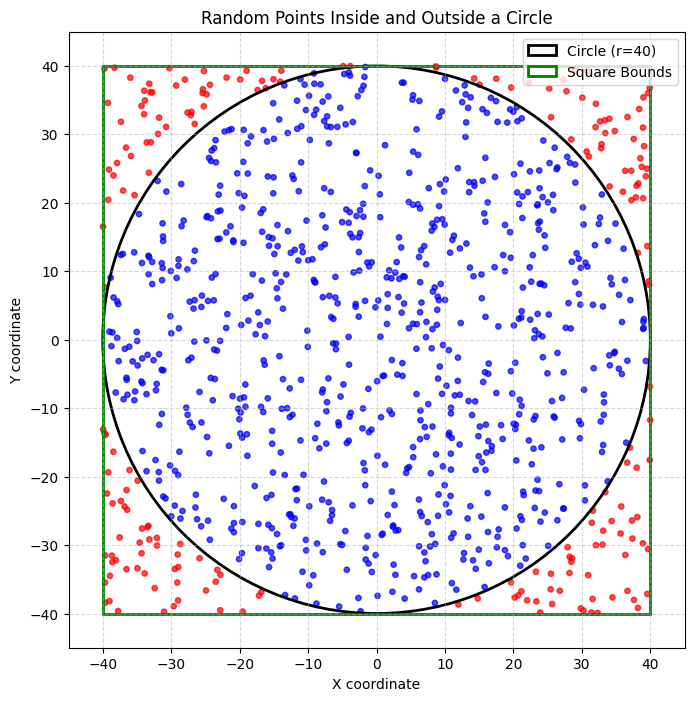

In [14]:
n = 1000
r = 40
x, y =draw_random_point(r ,r ,n)
colors , color , count = pos_of_points(x, y , r )



def draw_graph(x: NDArray, y: NDArray, colors: NDArray):
    plt.figure(figsize=(8, 8))
    
    # Map 0 to 'blue' and 1 to 'red'
    color_map = np.where(colors == 0, 'blue', 'red')
    
    # Draw the scatter plot
    plt.scatter(x, y, c=color_map, s=15, alpha=0.7)
    
    # Draw the boundary circle (radius 20)
    circle = Circle((0, 0), r, color='black', fill=False, linewidth=2, label=f'Circle (r={r})')
    plt.gca().add_patch(circle)
    
    # Draw the bounding square (from -20 to 20, so length is 40)
    square = Rectangle((-r, -r), 2*r, 2*r, color='green', fill=False, linewidth=2, label='Square Bounds')
    plt.gca().add_patch(square)
    
    # Formatting the plot
    plt.xlim(-r-5, r+5)
    plt.ylim(-r-5, r+5)
    
    # Ensure the aspect ratio is 1:1 so the circle isn't stretched into an oval
    plt.gca().set_aspect('equal') 
    
    plt.title("Random Points Inside and Outside a Circle")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.legend(loc="upper right")
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Call the drawing function
draw_graph(x, y, colors)